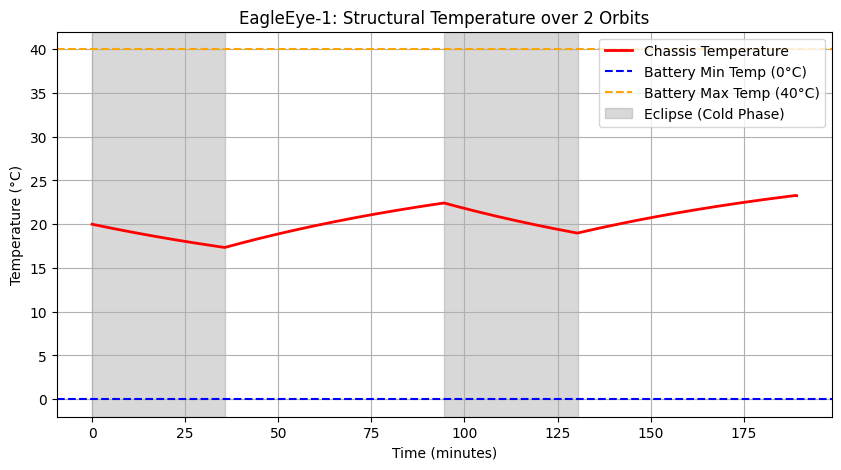

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PARAMETERS
mass_kg = 4.0
specific_heat_al = 897.0 
area_m2 = 0.14 
emissivity = 0.8 
absorptivity = 0.2 # Chasis de aluminio anodizado oscuro + Silver FEP (0.9 --> 0.2)

sigma = 5.67e-8 

solar_flux = 1361.0  
earth_ir = 237.0     
albedo = solar_flux * 0.3 

period_min = 94.62
eclipse_min = 35.76

# 2. SIMULATION SETUP
time_min = np.linspace(0, period_min * 2, 1000)
time_sec = time_min * 60.0
dt = time_sec[1] - time_sec[0]

temperature_K = np.zeros(len(time_sec))
temperature_K[0] = 293.15 

P_internal = 15.0 

# 3. THERMAL LOOP (Euler Integration)
for i in range(1, len(time_sec)):
    t_orbit = time_min[i] % period_min
    
    if t_orbit > eclipse_min:
        Q_in = (solar_flux * absorptivity * (0.1 * 0.3)) + (albedo * absorptivity * (0.1 * 0.3)) + (earth_ir * emissivity * area_m2) + P_internal
    else:
        Q_in = (earth_ir * emissivity * area_m2) + P_internal
        
    Q_out = emissivity * sigma * area_m2 * (temperature_K[i-1]**4)
    
    dT = ((Q_in - Q_out) / (mass_kg * specific_heat_al)) * dt
    temperature_K[i] = temperature_K[i-1] + dT

temperature_C = temperature_K - 273.15

# 4. VISUALIZATION
plt.figure(figsize=(10, 5))
plt.plot(time_min, temperature_C, 'r-', linewidth=2, label='Chassis Temperature')
plt.axhline(y=0, color='b', linestyle='--', label='Battery Min Temp (0°C)')
plt.axhline(y=40, color='orange', linestyle='--', label='Battery Max Temp (40°C)')
plt.axvspan(0, eclipse_min, color='gray', alpha=0.3, label='Eclipse (Cold Phase)')
plt.axvspan(period_min, period_min + eclipse_min, color='gray', alpha=0.3)

plt.title('EagleEye-1: Structural Temperature over 2 Orbits')
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.legend()
plt.show()